## What is a custom dataset?

A custom dataset is a collection of data relating to a specific problem you're working on.

In essence, a custom dataset can be comprised of almost anything.

For example, if we were building a food image classification app like Nutrify, our custom dataset might be images of food.

Or if we were trying to build a model to classify whether or not a text-based review on a website was positive or negative, our custom dataset might be examples of existing customer reviews and their ratings.

Or if we were trying to build a sound classification app, our custom dataset might be sound samples alongside their sample labels.

Or if we were trying to build a recommendation system for customers purchasing things on our website, our custom dataset might be examples of products other people have bought.

## What we're going to cover

We're going to be applying the PyTorch Workflow we covered in notebook 01 and notebook 02 to a computer vision problem.

But instead of using an in-built PyTorch dataset, we're going to be using our own dataset of pizza, steak and sushi images.

The goal will be to load these images and then build a model to train and predict on them.

What we're going to build. We'll use torchvision.datasets as well as our own custom Dataset class to load in images of food and then we'll build a PyTorch computer vision model to hopefully be able to classify them.

![Screenshot 2026-03-30 105349.png](<attachment:Screenshot 2026-03-30 105349.png>)
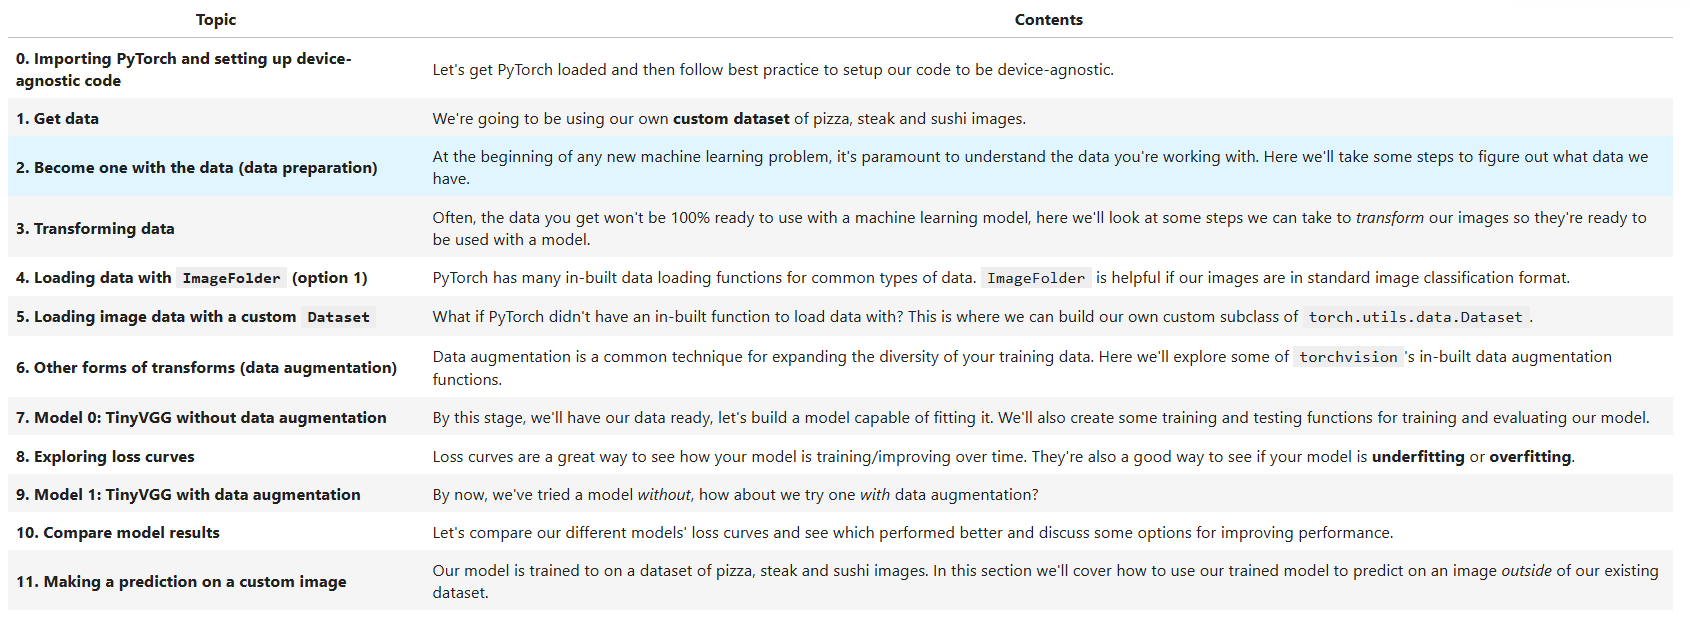

## 0. Importing PyTorch and setting up device-agnostic code

In [1]:
import torch
from torch import nn

In [2]:
## Setting up device ignostic code
device = 'cuda' if torch.cuda.is_available() else 'cpu'

device

'cuda'

## 1. Get data

The data we're going to be using is a subset of the Food101 dataset.

Food101 is popular computer vision benchmark as it contains 1000 images of 101 different kinds of foods, totaling 101,000 images (75,750 train and 25,250 test).

Instead of 101 food classes though, we're going to start with 3: pizza, steak and sushi.

And instead of 1,000 images per class, we're going to start with a random 10% (start small, increase when necessary).

If you'd like to see where the data came from you see the following resources:

* Original Food101 dataset and paper website.
* torchvision.datasets.Food101 - the version of the data I downloaded for this notebook.
* extras/04_custom_data_creation.ipynb - a notebook I used to format the Food101 dataset to use for this notebook.
* data/pizza_steak_sushi.zip - the zip archive of pizza, steak and sushi images from Food101, created with the notebook linked above.

In [3]:
import requests
import zipfile
from pathlib import Path

## Setup path to a data folder
data_path = Path('data/')
image_path = data_path / "pizza_steak_sushi" 

# if the img folder doesn't  exixt , download it and prepare it 

if image_path.is_dir():
    print(f"{image_path} Directory already exist")
else:
    print(f"{image_path} Does not exist , creating one...")
    image_path.mkdir(parents=True, exist_ok=True)

# Download
with open(data_path/ "pizza_steak_sushi.zip", "wb") as f:
    request = requests.get('https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip')
    print(f"Downloading the data")
    f.write(request.content)

## Unziping 
with zipfile.ZipFile(data_path / 'pizza_steak_sushi.zip', 'r') as zip_ref:
    print(f"Unziping pizza steak sushi data...")
    zip_ref.extractall(image_path)   # extracted to image_path folder(pizza_steak_sushi) as `Test And Train`

data\pizza_steak_sushi Directory already exist
Unziping pizza steak sushi data...


## 2. Becoming one with the data (data exploration and preparation)

In [4]:
import os 
def walk_thorugh_dir(dir_path):
    '''Walks through dir_path returning it's contents'''
    for dirpath , dirnames , filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directoires and {len(filenames)} imgs in '{dirpath}'. ")

In [5]:
walk_thorugh_dir(image_path)

There are 2 directoires and 0 imgs in 'data\pizza_steak_sushi'. 
There are 3 directoires and 0 imgs in 'data\pizza_steak_sushi\test'. 
There are 0 directoires and 25 imgs in 'data\pizza_steak_sushi\test\pizza'. 
There are 0 directoires and 19 imgs in 'data\pizza_steak_sushi\test\steak'. 
There are 0 directoires and 31 imgs in 'data\pizza_steak_sushi\test\sushi'. 
There are 3 directoires and 0 imgs in 'data\pizza_steak_sushi\train'. 
There are 0 directoires and 78 imgs in 'data\pizza_steak_sushi\train\pizza'. 
There are 0 directoires and 75 imgs in 'data\pizza_steak_sushi\train\steak'. 
There are 0 directoires and 72 imgs in 'data\pizza_steak_sushi\train\sushi'. 


In [6]:
## setup training and  testing paths
train_dir = image_path / 'train'
test_dir = image_path / 'test'

train_dir, test_dir

(WindowsPath('data/pizza_steak_sushi/train'),
 WindowsPath('data/pizza_steak_sushi/test'))

![Screenshot 2026-03-30 161939.png](<attachment:Screenshot 2026-03-30 161939.png>)

`The goal will be to take this data storage structure and turn it into a dataset usable with PyTorch.`
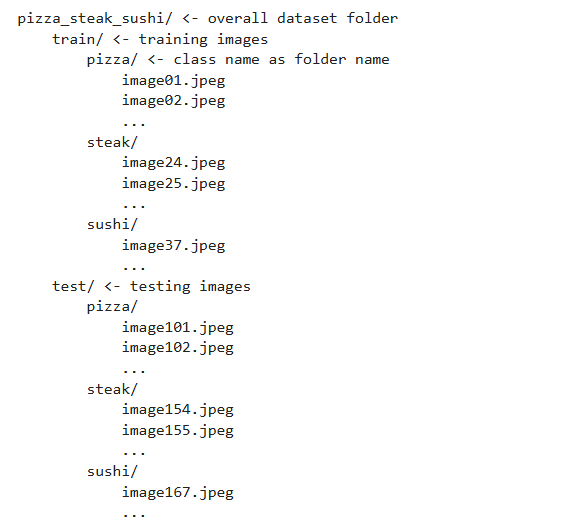

### 2.1 Visualize the  image


1. Get all of the image paths using pathlib.Path.glob() to find all of the files ending in .jpg.
2. Pick a random image path using Python's random.choice().
3. Get the image class name using pathlib.Path.parent.stem.
4. And since we're working with images, we'll open the random image path using PIL.Image.open() (PIL stands for Python Image Library).
5. We'll then show the image and print some metadata.

Random image Path : data\pizza_steak_sushi\train\sushi\1138695.jpg
image Class : sushi
Image height : 512
Image Width : 512


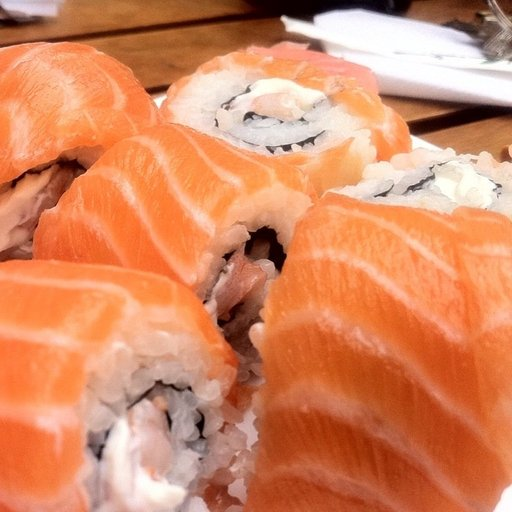

In [7]:
import random
from PIL import Image

# seed
# random.seed(42)

# 1. get all image paths
image_path_list = list(image_path.glob("*/*/*.jpg"))

# 2. pick a random img path 

random_image_path = random.choice(image_path_list)
# print(random_image_path)

# 3.  Get img class from path name (image class is the name of directory where img is stored)
image_class =  random_image_path.parent.stem
# print(image_class)

# 4 open image
img = Image.open(random_image_path)

# 5. print metaData
print(f"Random image Path : {random_image_path}")
print(f"image Class : {image_class}")
print(f"Image height : {img.height}")
print(f"Image Width : {img.width}")
img



In [8]:
## try to visualize img with matplotlib
import matplotlib.pyplot as plt
import numpy as np

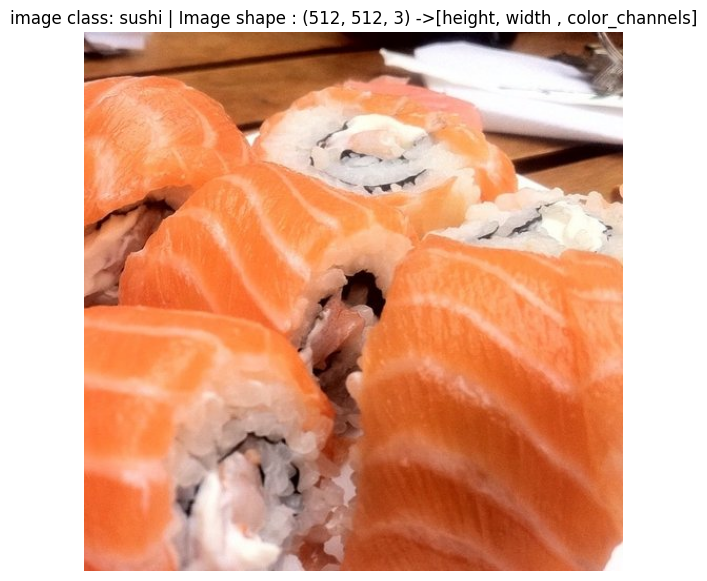

In [9]:
# img to array
img_as_array = np.asarray(img) 
plt.figure(figsize=(10,7))
plt.imshow(img_as_array)
plt.title(f"image class: {image_class} | Image shape : {img_as_array.shape} ->[height, width , color_channels]")
plt.axis(False);



## 3. Transforming Data

Before we can use our image data with PyTorch, we need to transform it.
1. Turen your target data(in our case, numerical representation of our images).
2. Turn it into a `torch.utils.data.Dataset` and a subsequently a `torch.utils.data.DataLoader` we'll call these ``Dataset`` and ``DataLoader`` respectively.

In [10]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


### 3.1 Transforming data with torchvision.transforms

In [11]:
#3 write a transform for img
data_transform = transforms.Compose([
    # Resize our images to 64x64
    transforms.Resize(size=(64,64)),
    # Flip the images randomly on horizontal
    transforms.RandomHorizontalFlip(p=0.5),
    # TURN THE IMAGE IN TORCH TENSOR    
    transforms.ToTensor()
])

## understand this is for transforming single img let's write code from transforming every img out there

In [12]:
data_transform(img).dtype


torch.float32

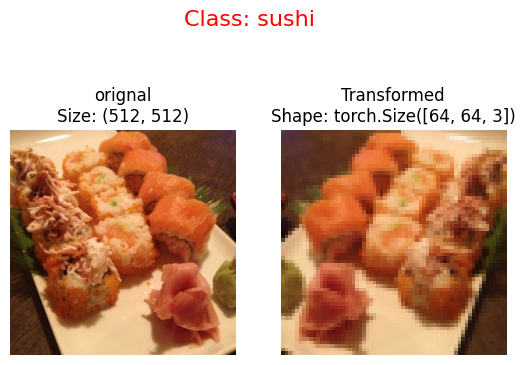

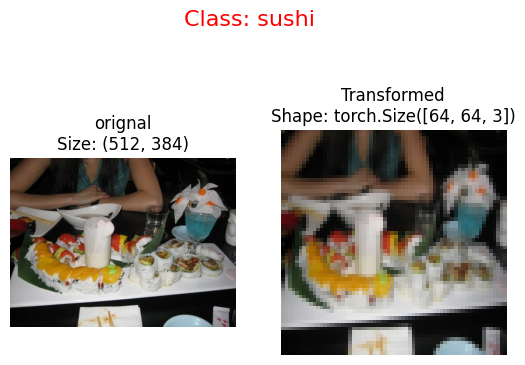

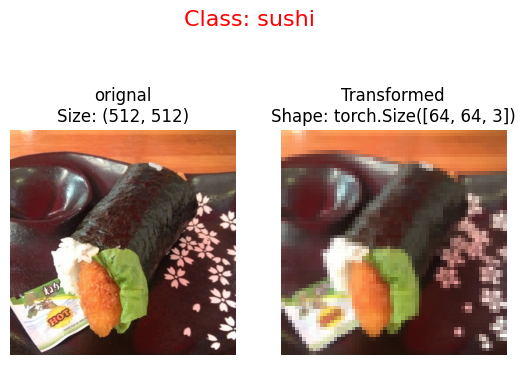

In [13]:
def plot_transformed_images(image_paths : list, transform , n=3, seed=None):
     '''
     Selects random images from a path of imgs and loads/transforms
     them then plot the orignal vs the transformed version
     '''
     if seed:
          random.seed(seed)
     random_image_paths = random.sample(image_paths, k=n) # N = ? tells how many images want 
     for image_path in random_image_paths:
          with Image.open(image_path) as f:
               fig , ax = plt.subplots(nrows=1,ncols=2)
               ax[0].imshow(f)
               ax[0].set_title(f"orignal\nSize: {f.size}")
               ax[0].axis(False)

               # Transform and plot image
               # Note: permute() will change shape of image to suit matplotlib 
               # (PyTorch default is [C, H, W] but Matplotlib is [H, W, C])
               transformed_image = transform(f).permute(1,2,0) # C is going in last as matplotlib needs [H W C]
               ax[1].imshow(transformed_image)
               ax[1].set_title(f"Transformed\nShape: {transformed_image.shape}")
               ax[1].axis("off")

               fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16,c='red')

plot_transformed_images(image_paths=image_path_list,
                        transform=data_transform,
                        n=3,
                        seed=None)

## 4. option 1: Loading data with torchvision.datasets.ImageFolder

Since our data is in standard image classification format, we can use the class torchvision.datasets.ImageFolder.

Where we can pass it the file path of a target image directory as well as a series of transforms we'd like to perform on our images.

Let's test it out on our data folders train_dir and test_dir passing in transform=data_transform to turn our images into tensors.

In [14]:
# Use ImageFolder to create dataset(s)
from torchvision import datasets
train_data = datasets.ImageFolder(root= train_dir,
                                  transform= data_transform, # a transform for the data
                                  target_transform=None) # a trtansform for the label/target

test_data = datasets.ImageFolder(root=test_dir,
                                 transform=data_transform,
                                 target_transform=None)

train_data, test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data\pizza_steak_sushi\train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data\pizza_steak_sushi\test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [15]:
## get class names as list
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [16]:
# get class names as dictionary
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [17]:
#3 check then lenght of dataset
len(train_data),len(test_data)

(225, 75)

In [18]:
##  Index on the train_data Dataset to get a single image and label
img , label = train_data[0][0] , train_data[0][1]  # train_data[0] -> this has img-tensor and it's label try it , So //train_data[0][0] -> img// & //train_data[0][1] -> label//

print(f"image tensor :- {img}")
print(f"Label :- {label} that is {class_names[label]}")
print(f"Image  Datatype : {img.dtype}")
print(f"Image Shape : {img.shape}")
print(f"Label Datatype : {type(label)}")

image tensor :- tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
         [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
         [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
         ...,
         [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
         [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0902],
         [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],

        [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
         [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0745],
         [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
         ...,
         [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
         [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
         [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],

        [[0.0196, 0.0196, 0.0157,  ..., 0.0902, 0.0902, 0.0941],
         [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
         [0.0196, 0.0157, 0.0157,  ..., 0.

Orignal shape :torch.Size([3, 64, 64])
Image permute :torch.Size([64, 64, 3])


Text(0.5, 1.0, 'pizza')

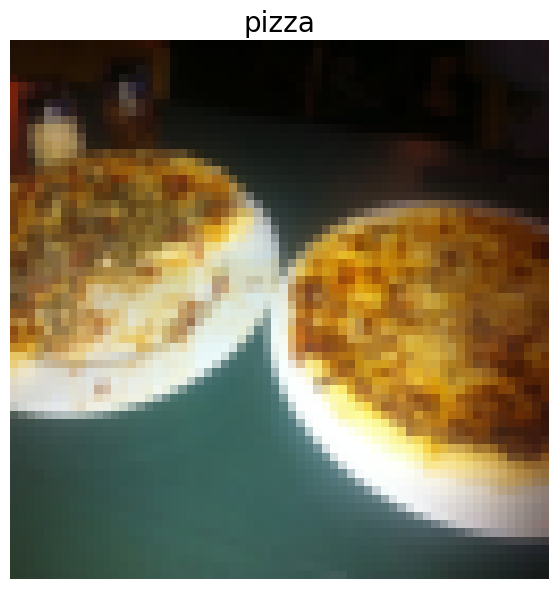

In [19]:
## rearrange the order dimensions
img_permute = img.permute(1,2,0)

# print out different shapes
print(f"Orignal shape :{img.shape}")
print(f"Image permute :{img_permute.shape}")

#plot the img

plt.figure(figsize=(10,7))
plt.imshow(img_permute)
plt.axis('off')
plt.title(class_names[label], fontsize=20)

## 4.1 Turn loaded images into DataLoader
A `Dataloader` is going to help us turn our Dataset's into iterables and we can constomise the `bathc_size` so our model can look at more than one sample at a time as well as `shuffle` our data so our model doesn't learn any spurious patterns in the order of our data.

In [20]:
import os 
os.cpu_count()

12

In [21]:
from torch.utils.data import DataLoader
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=32,
                              shuffle=True,
                              num_workers=os.cpu_count())
test_dataloader = DataLoader(dataset=test_data,
                             batch_size=32,
                             num_workers=os.cpu_count())

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x2117aaf0980>,
 <torch.utils.data.dataloader.DataLoader at 0x2117aeaa0d0>)

In [22]:
len(train_dataloader), len(test_dataloader)

(8, 3)

In [23]:
img , label = next(iter(train_dataloader))

# batch_size  change as you need

print(f"image Shape: {img.shape}")
print(f"Label Shape {label.shape}")  

image Shape: torch.Size([32, 3, 64, 64])
Label Shape torch.Size([32])


So now we have total 32 batch and each batch has 32 imges and their labels.

## 5. Option 2: Building a custom Data loading class with torch.utils.data.Dataset 

![Screenshot 2026-03-31 134925.png](<attachment:Screenshot 2026-03-31 134925.png>)

We'll start by importing the modules we need:

* Python's os for dealing with directories (our data is stored in directories).
* Python's pathlib for dealing with filepaths (each of our images has a unique filepath).
* torch for all things PyTorch.
* PIL's Image class for loading images.
* torch.utils.data.Dataset to subclass and create our own custom Dataset.
* torchvision.transforms to turn our images into tensors.
* Various types from Python's typing module to add type hints to our code.
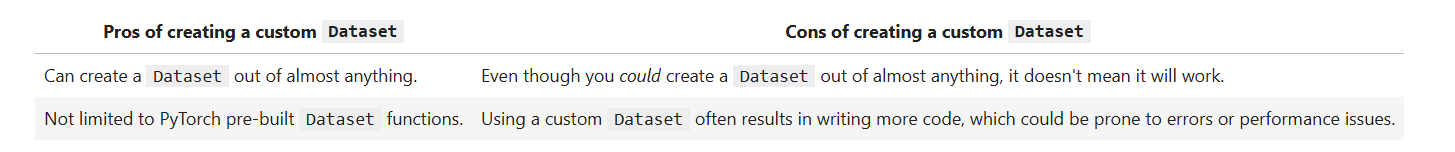

In [24]:
import os 
import pathlib
import torch

from PIL import Image
from torch.utils.data import Dataset
from  torchvision import transforms
from typing import Tuple, Dict, List



In [25]:
#3 Instance of torchvision.datasets.ImageFolder()
train_data.classes , train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

## 5.1 Creating a helper function to get class names

To do so, we'll:

1. Get the class names using os.scandir() to traverse a target directory (ideally the directory is in standard image classification format).
2. Raise an error if the class names aren't found (if this happens, there might be something wrong with the directory structure).
3. Turn the class names into a dictionary of numerical labels, one for each class.

Let's see a small example of step 1 before we write the full function.

In [26]:
## setup the path directory
target_directory = train_dir
print(f"target dir : {target_directory}")

# get the class names from the target directory 
class_names_found = sorted([entry.name for entry in list(os.scandir(target_directory))])
class_names_found

target dir : data\pizza_steak_sushi\train


['pizza', 'steak', 'sushi']

In [27]:
list(os.scandir(target_directory))

[<DirEntry 'pizza'>, <DirEntry 'steak'>, <DirEntry 'sushi'>]

In [28]:
def find_classes(directory: str) -> Tuple[List[str], Dict[str, int]]:
    '''Finds tahe classes folder name in target directory'''
    # 1. Get the class names by scanning the  target directory
    classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())
    
    # 2. Raise an error if class names could not be found 
    if not classes:
        raise FileNotFoundError(f"Couldn't find any classes in {directory}... please check the file structure.")
    
    # 3. create a dictionary of index labels 
    class_to_idx = {class_name : i for i, class_name in enumerate(classes)}
    return classes , class_to_idx

In [29]:
find_classes(target_directory)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### 5.2 Create a custom `Dataset` to replicate `ImageFolder`

We'll build one to replicate the functionality of torchvision.datasets.ImageFolder().

This will be good practice, plus, it'll reveal a few of the required steps to make your own custom Dataset.

Let's break it down:

1. Subclass torch.utils.data.Dataset.
2. Initialize our subclass with a targ_dir parameter (the target data directory) and transform parameter (so we have the option to transform our data if needed).
3. Create several attributes for paths (the paths of our target images), transform (the transforms we might like to use, this can be None), classes and class_to_idx (from our find_classes() function).
4. Create a function to load images from file and return them, this could be using PIL or torchvision.io (for input/output of vision data).
5. Overwrite the __len__ method of torch.utils.data.Dataset to return the number of samples in the Dataset, this is recommended but not required. This is so you can call len(Dataset).
6. Overwrite the __getitem__ method of torch.utils.data.Dataset to return a single sample from the Dataset, this is required.

In [30]:
# 0. write a custom dataset class
from torch.utils.data import Dataset

# 1. Subclass torch.utils.data.Dataset
class ImageFolderCustom(Dataset):   # taking all functionality form Dataset (above) 
    # 2. Initilize our custom Dataset
    def __init__(self,
                targ_dir:str,
                transform =None):
        # 3. Create class atributes
        # get all of the image paths
        self.paths = list(pathlib.Path(targ_dir).glob("*/*.jpg"))
        # setup Tarnsforms
        self.transform = transform
        # create  classes and classes_to_idx attribute
        self.classes, self.class_to_idx =(find_classes(targ_dir))

    # 4. Create a function to load images 
    def load_images(self, index: int) -> Image.Image:
        """Opens an image via a path and returns it"""
        image_path = self.paths[index]
        return Image.open(image_path)

    # 5. Overwrite __len__()
    def __len__(self) -> int:
        "Returns the total number of samples"
        return len(self.paths)
    
    # 6. Overwrite __getitem__() method to return a particular sample 
    def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:   # it's img, label as img-> tensor, label-> int we can see it in last when we print img,label
        'Returns one sample of data and label (X,y)'
        img = self.load_images(index)
        class_name = self.paths[index].parent.name # expects path in format: data-foldr/class_names/image.jpg
        class_idx = self.class_to_idx[class_name]

        ## transform if necessary
        if self.transform:
            return self.transform(img), class_idx ## return data , label
        else:
            return img , class_idx # return untransformed img & label 


In [31]:
# create a transform
from torchvision import transforms
train_transform = transforms.Compose([
                                    transforms.Resize(size=(64,64)),
                                    transforms.RandomHorizontalFlip(p=0.5),
                                    transforms.ToTensor()
])

test_transforms = transforms.Compose([
                                transforms.Resize(size=(64,64)),
                                transforms.ToTensor()
])

In [32]:
# Test out ImageFolderCustom
train_data_custom = ImageFolderCustom(targ_dir=train_dir,
                                      transform=train_transform)

test_data_custom = ImageFolderCustom(targ_dir = test_dir,
                                     transform = test_transforms)

In [33]:
train_data_custom, test_data_custom

(<__main__.ImageFolderCustom at 0x2117aaf1a90>,
 <__main__.ImageFolderCustom at 0x2117acb4050>)

In [34]:
len(train_data), len(train_data_custom)

(225, 225)

In [35]:
len(test_data), len(test_data_custom)

(75, 75)

In [36]:
# Check for equality amongst our custom Dataset and ImageFolder Dataset
print((len(train_data_custom) == len(train_data)) & (len(test_data_custom) == len(test_data)))
print(train_data_custom.classes == train_data.classes)
print(train_data_custom.class_to_idx == train_data.class_to_idx)

True
True
True


### 5.3 Create a function to display random images from our custom Dataset

Specifically, it'll:

1) Take in a Dataset and a number of other parameters such as classes (the names of our target classes), the number of images to display (n) and a random seed.
2) To prevent the display getting out of hand, we'll cap n at 10 images.
3) Set the random seed for reproducible plots (if seed is set).
4) Get a list of random sample indexes (we can use Python's random.sample() for this) to plot.
5) Setup a matplotlib plot.
6) Loop through the random sample indexes found in step 4 and plot them with matplotlib.
7) Make sure the sample images are of shape HWC (height, width, color channels) so we can plot them.

In [37]:
## 1. Create a function to take in a dataset
def display_random_images(dataset : torch.utils.data.Dataset,
                            classes : List[str] = None,
                            n : int = 10,
                            display_shape : bool = True,
                            seed : int = None ):
    # 2. Adjust display if n is too High
    if n > 10:
        n = 10
        display_shape = False
        print(f"For display, purposes, n shouldn't be larger than 10, setting to 10 and removing shape display ")
     
    # 3. Set seed
    if seed:
        random.seed(seed)

    # 4. get random sample indexes
    random_sample_idx = random.sample(range(len(dataset)), k=n)

    # 5. Setup plot
    plt.figure(figsize =(16,8))

    # 6. Loop through random indexes and plot them with matplotlib

    for i , targ_sample in enumerate(random_sample_idx):
        targ_img , targ_label = dataset[targ_sample][0] , dataset[targ_sample][1]

        # 7. Adjust tensor dimension for plotting
        targ_image_adjust = targ_img.permute(1,2,0)
        
        # Plot adjusted samples
        plt.subplot(1, n, i+1)
        plt.imshow(targ_image_adjust)
        plt.axis("off")
        if classes:
            title =  f"class: {classes[targ_label]}"
            if display_shape:
                title = title + f"\n shape: {targ_image_adjust.shape}"
            plt.title(title)

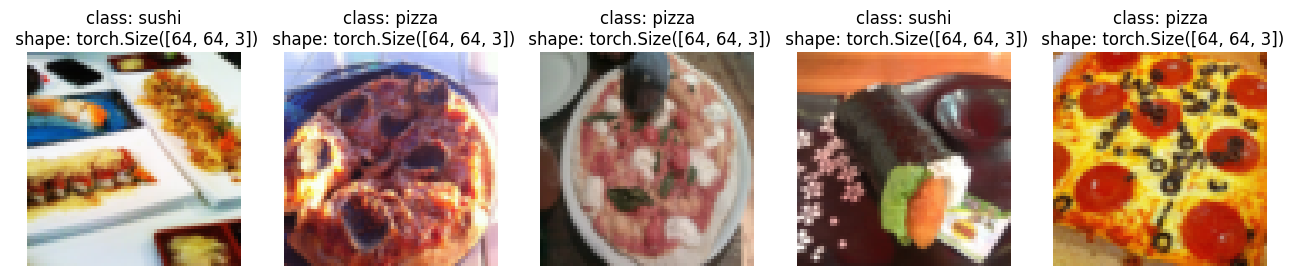

In [38]:
# Display random images from ImageFolder  created Dataset
display_random_images(train_data,
                      n=5,
                      classes = class_names,
                      seed = 42)

For display, purposes, n shouldn't be larger than 10, setting to 10 and removing shape display 


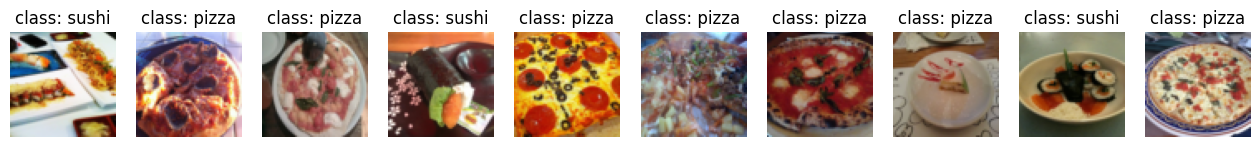

In [39]:
# Display random images from the ImageFolderCustom Dataset
display_random_images(train_data_custom,
                      n=20,
                      classes= class_names,
                      seed = 42)

### 5.4 Turn custom loaded images into DataLoader's

We've got a way to turn our raw images into Dataset's (features mapped to labels or X's mapped to y's) through our ImageFolderCustom class.

Now how could we turn our custom Dataset's into DataLoader's?

If you guessed by using torch.utils.data.DataLoader(), you'd be right!

Because our custom Dataset's subclass torch.utils.data.Dataset, we can use them directly with torch.utils.data.DataLoader().

And we can do using very similar steps to before except this time we'll be using our custom created Dataset'

In [40]:
from torch.utils.data import DataLoader
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()
train_dataloader_custom = DataLoader(dataset = train_data_custom,
                                     batch_size=BATCH_SIZE,
                                     num_workers=0,
                                     shuffle=True)

test_dataloader_custom = DataLoader(dataset= test_data_custom,
                                    batch_size=BATCH_SIZE,
                                    num_workers=0,
                                    shuffle=False)

train_dataloader_custom, test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x2117aeaafd0>,
 <torch.utils.data.dataloader.DataLoader at 0x2117abbe520>)

In [41]:
# get image and label from custom dataloader
img_custom , label_custom = next(iter(train_dataloader_custom))

# print out the shape
img_custom.shape , label_custom.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

### 6. Other forms of transforms (data augmentation)

Data augmentation is the process of altering your data in such a way that you artificially increase the diversity of your training set.

Training a model on this artificially altered dataset hopefully results in a model that is capable of better generalization (the patterns it learns are more robust to future unseen examples).

You can see many different examples of data augmentation performed on images using torchvision.transforms in PyTorch's Illustration of Transforms example.

But let's try one out ourselves.

Machine learning is all about harnessing the power of randomness and research shows that random transforms (like transforms.RandAugment() and transforms.TrivialAugmentWide()) generally perform better than hand-picked transforms.

The idea behind TrivialAugment is... well, trivial.

You have a set of transforms and you randomly pick a number of them to perform on an image and at a random magnitude between a given range (a higher magnitude means more instense).

The PyTorch team even used TrivialAugment it to train their latest state-of-the-art vision models.

In [42]:
# let's go with trivialaugment
from torchvision import transforms

train_transform = transforms.Compose([
                                        transforms.Resize(size=(224,224)),
                                        transforms.TrivialAugmentWide(num_magnitude_bins=5),
                                        transforms.ToTensor()
])
test_transform = transforms.Compose([
                                    transforms.Resize(size=(224,224)),
                                    transforms.ToTensor()
])

In [43]:
## Get all the img paths
image_path_list = list(image_path.glob("*/*/*.jpg"))
image_path_list[:10]

[WindowsPath('data/pizza_steak_sushi/test/pizza/1152100.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/1503858.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/1687143.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/1925494.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/194643.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/195160.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2003290.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2019408.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2111981.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2124579.jpg')]

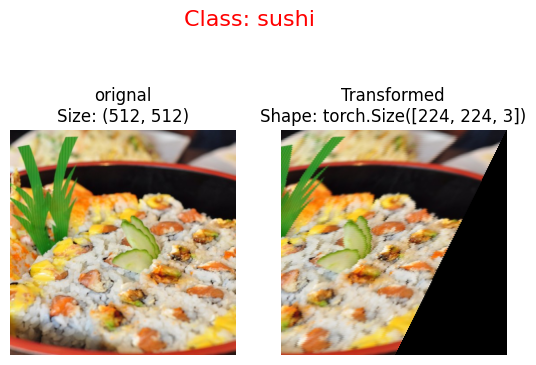

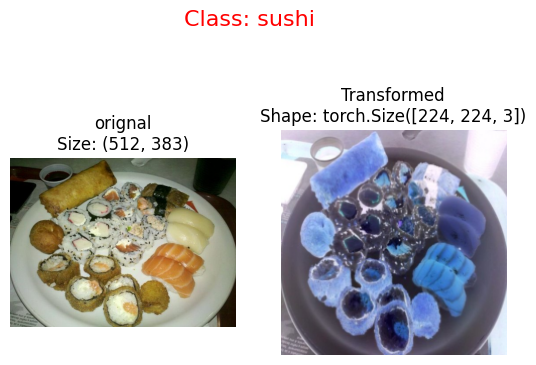

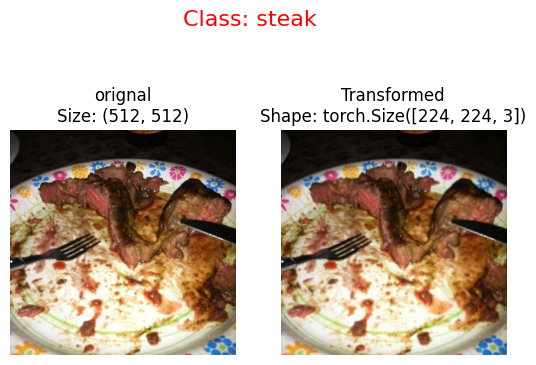

In [44]:
#plot random images
plot_transformed_images( # wee created this above
    image_paths=image_path_list,
    transform=train_transform,
    n=3,
    seed=None
)

## 7. Model 0: TinyVGG without data augmentaion

In [45]:
### 7.1 creating transforms and loading data for model 0
simple_transform = transforms.Compose([
                                    transforms.Resize(size=(64,64)),
                                    transforms.ToTensor()
])

In [46]:
#1. Load and transform data
from torchvision import datasets
train_data_simple = datasets.ImageFolder(root=train_dir,
                                         transform=simple_transform)
test_data_simple = datasets.ImageFolder(root=test_dir,
                                        transform=simple_transform)

# 2. turn the dataset into dataloaders
import os 
from torch.utils.data import DataLoader

# setup batch size and number of works
BATCH_SIZE = 32
NUM_WORKERS  = os.cpu_count()

# Create DataLoader

train_dataloader_simple = DataLoader(dataset=train_data_simple,
                                     batch_size=BATCH_SIZE,
                                     shuffle=True,
                                     num_workers=NUM_WORKERS,)

test_dataloader_simple = DataLoader(dataset=test_data_simple,
                                    batch_size=BATCH_SIZE,
                                    num_workers=NUM_WORKERS,
                                    shuffle=False)

### Create TinyVGG model class

In [47]:
class TinyVGG(nn.Module):
    '''
    Model architecture copying tinyVGG from CNN Explainer (so in/op is based on that website structure) 
    '''
    def __init__(self,input_shape: int,
                 hidden_units: int,
                 output_shape : int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=0),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=0),
            nn.ReLU(),
            nn.MaxPool2d(stride=2,
                         kernel_size=2) #  default value of stride is same as kernel_size
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=0),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=0),
            nn.ReLU(),
            nn.MaxPool2d(stride=2,
                         kernel_size=2) #  default value of stride is same as kernel_size
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*13*13,
                      out_features=output_shape)
        )
    def forward(self, x):
        x = self.conv_block_1(x)
        # print(x.shape)
        x = self.conv_block_2(x)
        # print(x.shape)
        x = self.classifier(x)
        # print(x.shape)
        return x
        # return self.classifier(self.conv_block_2(self.conv_block_1(x)))   # Benefits from operator fusion

In [48]:
torch.manual_seed(42)
model_0 = TinyVGG(input_shape=3,   # number of color channels in our image data
                  hidden_units=10,
                  output_shape=len(class_names)).to(device)

model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=3, bias=True)
  )
)

### Try a forward pass on a single image (to test the model)

In [49]:
# get  a single image batch
image_batch, label_batch = next(iter(train_dataloader_simple))
image_batch.shape ,label_batch.shape


(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [50]:
# Try a forward pass
model_0(image_batch.to(device))

tensor([[ 2.0795e-02, -1.9510e-03,  9.5212e-03],
        [ 1.8440e-02,  2.4669e-03,  6.6609e-03],
        [ 1.7695e-02,  1.0282e-03,  9.4975e-03],
        [ 2.4446e-02, -3.3489e-03,  9.5877e-03],
        [ 1.9939e-02,  6.9127e-04,  1.0778e-02],
        [ 2.1281e-02,  2.0434e-03,  5.0046e-03],
        [ 2.0996e-02,  1.6415e-04,  1.2481e-02],
        [ 2.1566e-02, -1.9607e-03,  9.7175e-03],
        [ 2.4500e-02, -4.7904e-03,  8.5394e-03],
        [ 2.0238e-02, -4.7979e-04,  1.0907e-02],
        [ 2.2219e-02, -4.1816e-04,  9.8173e-03],
        [ 2.2318e-02, -2.1642e-03,  9.4428e-03],
        [ 2.1851e-02, -3.7226e-03,  8.3785e-03],
        [ 2.2881e-02, -1.7559e-03,  1.0299e-02],
        [ 2.1635e-02, -4.3994e-03,  9.4990e-03],
        [ 2.2101e-02, -4.1469e-03,  9.3904e-03],
        [ 2.1226e-02, -4.4215e-03,  1.1476e-02],
        [ 2.1698e-02, -2.7458e-03,  8.4966e-03],
        [ 1.9974e-02, -3.2131e-07,  8.4496e-03],
        [ 1.8308e-02,  1.6378e-03,  8.5491e-03],
        [ 2.0768e-02

In [51]:
%pip install torchinfo

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [52]:
from torchinfo import summary
summary(model_0 ,input_size=[1,3,64,64])

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 30, 30]           --
│    └─Conv2d: 2-1                       [1, 10, 62, 62]           280
│    └─ReLU: 2-2                         [1, 10, 62, 62]           --
│    └─Conv2d: 2-3                       [1, 10, 60, 60]           910
│    └─ReLU: 2-4                         [1, 10, 60, 60]           --
│    └─MaxPool2d: 2-5                    [1, 10, 30, 30]           --
├─Sequential: 1-2                        [1, 10, 13, 13]           --
│    └─Conv2d: 2-6                       [1, 10, 28, 28]           910
│    └─ReLU: 2-7                         [1, 10, 28, 28]           --
│    └─Conv2d: 2-8                       [1, 10, 26, 26]           910
│    └─ReLU: 2-9                         [1, 10, 26, 26]           --
│    └─MaxPool2d: 2-10                   [1, 10, 13, 13]           --
├─Sequentia

### 7.5 Create train and test loops functions
* `train_step()` - takes a model and dataloader and trains the model on the data from the dataloader.
8 `test_step()` - takes in a model and dataloader and evaluates the model on the data from the dataloader.

In [53]:
## create a train_step()

def train_step(model : torch.nn.Module,
               dataloader : torch.utils.data.DataLoader,
               loss_fn : torch.nn.Module,
               optimizer : torch.optim.Optimizer):
    model.train()

    # setup train loss and train accuaracy values
    train_loss , train_acc = 0,0

    # loop through data loader dta batches
    for batch , (X,y) in enumerate(dataloader):
        # send data to the targ device
        X , y = X.to(device) , y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate the loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        #4. loss backward 
        loss.backward()

        # 5. optimizer Step
        optimizer.step()

        # calculate accuarcy metric

        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

        # Adjust ,metrics to get avg loss and accuracy loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)

    return train_loss ,train_acc

In [54]:
def test_step(model: torch.nn.Module, 
              dataloader: torch.utils.data.DataLoader, 
              loss_fn: torch.nn.Module,
              device = device):
    # Put model in eval mode
    model.eval() 
    
    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0

    with torch.inference_mode():
        # loop through dataloader batches

        for batch, (X,y) in enumerate(dataloader):
            # send data to the target device
            X, y = X.to(device) , y.to(device)

            # forward pass
            test_pred_logits = model(X)

            #  cal loss
            loss = loss_fn(test_pred_logits , y)
            test_loss += loss.item()

            # cal the acc
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item() / len(test_pred_labels))

            # adjust metric to get avg loss and accuracy per batch

        test_loss = test_loss / len(dataloader)
        test_acc = test_acc / len(dataloader)

        return test_loss , test_acc

### 7.6 Creating a train() function to combine train_step() and test_step()

Now we need a way to put our train_step() and test_step() functions together.

To do so, we'll package them up in a train() function.

This function will train the model as well as evaluate it.

Specificially, it'll:

1. Take in a model, a DataLoader for training and test sets, an optimizer, a loss function and how many epochs to perform each train and test step for.
2. Create an empty results dictionary for train_loss, train_acc, test_loss and test_acc values (we can fill this up as training goes on).
3. Loop through the training and test step functions for a number of epochs.
4. Print out what's happening at the end of each epoch.
5. Update the empty results dictionary with the updated metrics each epoch.
6. Return the filled results dictionary.
To keep track of the number of epochs we've been through, let's import tqdm from tqdm.auto (tqdm is one of the most popular progress bar libraries for Python and tqdm.auto automatically decides what kind of progress bar is best for your computing environment, e.g. Jupyter Notebook vs. Python script).

In [55]:
from tqdm.auto import tqdm

# 1. take in various parameters required for traiing and test steps 

def train(model : torch.nn.Module,
          train_dataloader : torch.utils.data.DataLoader,
          test_dataloader : torch.utils.data.DataLoader,
          optimizer : torch.optim.Optimizer,
          loss_fn : torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):
    # 2. Create empty result dictionary 
    results = {"train_loss" : [],
               "train_acc": [],
               "test_loss": [],
               "test_acc": []
               }
    # 3. Loop through the train and tessting loops  for the number for epochs 
    for epoch in tqdm(range(epochs)):
        train_loss , train_acc = train_step(model = model,
                                            dataloader = train_dataloader,
                                            
                                            loss_fn = loss_fn,
                                            optimizer = optimizer )
        test_loss , test_acc  = test_step(model = model,
                                          dataloader= test_dataloader,
                                          loss_fn = loss_fn)
        # 4. print out what's happening
        print(
            f"Epoch : {epoch+1} | tarin_loss : {train_loss:.4f} | train_acc : {train_acc:.4f} | test_loss: {test_loss:.4f} | test_acc : {test_acc:.4f} "
        ) 

        #5. Update result directory
        # ensure all data is moved to cpu and converted  to float for storage
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss )
        results["train_acc"].append(train_acc.item() if isinstance(train_acc , torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    # 6. Return the filled results at the end of the epochs
    return results

###  7.7 Train and Evaluate Model 0

Time to put our TinyVGG model, DataLoader's and train() function together to see if we can build a model capable of discerning between pizza, steak and sushi!

Let's recreate model_0 (we don't need to but we will for completeness) then call our train() function passing in the necessary parameters.

To keep our experiments quick, we'll train our model for 5 epochs (though you could increase this if you want).

As for an optimizer and loss function, we'll use torch.nn.CrossEntropyLoss() (since we're working with multi-class classification data) and torch.optim.Adam() with a learning rate of 1e-3 respectively.

To see how long things take, we'll import Python's timeit.default_timer() method to calculate the training time.

In [56]:
# Set random seeds
torch.manual_seed(42) 
torch.cuda.manual_seed(42)

# Set number of epochs
NUM_EPOCHS = 5

# Recreate an instance of TinyVGG
model_0 = TinyVGG(input_shape=3, # number of color channels (3 for RGB) 
                  hidden_units=10, 
                  output_shape=len(train_data.classes)).to(device)

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)

# Start the timer
from timeit import default_timer as timer 
start_time = timer()

# Train model_0 
model_0_results = train(model=model_0, 
                        train_dataloader=train_dataloader_simple,
                        test_dataloader=test_dataloader_simple,
                        optimizer=optimizer,
                        loss_fn=loss_fn, 
                        epochs=NUM_EPOCHS)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time - start_time:.3f} seconds")                    

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch : 1 | tarin_loss : 1.1063 | train_acc : 0.3047 | test_loss: 1.0983 | test_acc : 0.3011 
Epoch : 2 | tarin_loss : 1.0998 | train_acc : 0.3281 | test_loss: 1.0697 | test_acc : 0.5417 
Epoch : 3 | tarin_loss : 1.0869 | train_acc : 0.4883 | test_loss: 1.0808 | test_acc : 0.4924 
Epoch : 4 | tarin_loss : 1.0844 | train_acc : 0.3984 | test_loss: 1.0607 | test_acc : 0.5833 
Epoch : 5 | tarin_loss : 1.0663 | train_acc : 0.4180 | test_loss: 1.0657 | test_acc : 0.5644 
Total training time: 99.043 seconds


### 7.8 Plot the loss curves of Model 0

Loss curves show the model's results over time.

And they're a great way to see how your model performs on different datasets (e.g. training and test).

In [57]:
# Check the model_0_results keys
model_0_results.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc'])

In [58]:
def plot_loss_curves(results: Dict[str, List[float]]):
    """Plots training curves of a results dictionary.

    Args:
        results (dict): dictionary containing list of values, e.g.
            {"train_loss": [...],
             "train_acc": [...],
             "test_loss": [...],
             "test_acc": [...]}
    """
    
    # Get the loss values of the results dictionary (training and test)
    loss = results['train_loss']
    test_loss = results['test_loss']

    # Get the accuracy values of the results dictionary (training and test)
    accuracy = results['train_acc']
    test_accuracy = results['test_acc']

    # Figure out how many epochs there were
    epochs = range(len(results['train_loss']))

    # Setup a plot 
    plt.figure(figsize=(15, 7))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='train_loss')
    plt.plot(epochs, test_loss, label='test_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='train_accuracy')
    plt.plot(epochs, test_accuracy, label='test_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend();

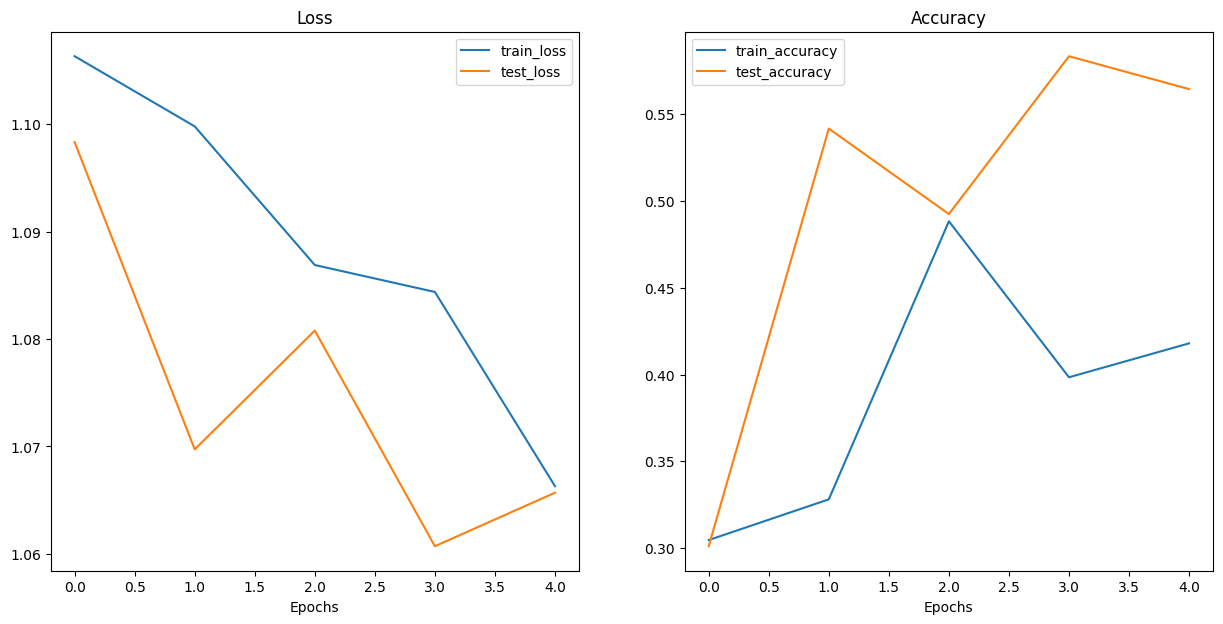

In [59]:
plot_loss_curves(model_0_results)

### 8. What should an ideal loss curve look like?

Looking at training and test loss curves is a great way to see if your model is overfitting.

An overfitting model is one that performs better (often by a considerable margin) on the training set than the validation/test set.

If your training loss is far lower than your test loss, your model is overfitting.

As in, it's learning the patterns in the training too well and those patterns aren't generalizing to the test data.

The other side is when your training and test loss are not as low as you'd like, this is considered underfitting.

The ideal position for a training and test loss curve is for them to line up closely with each other.

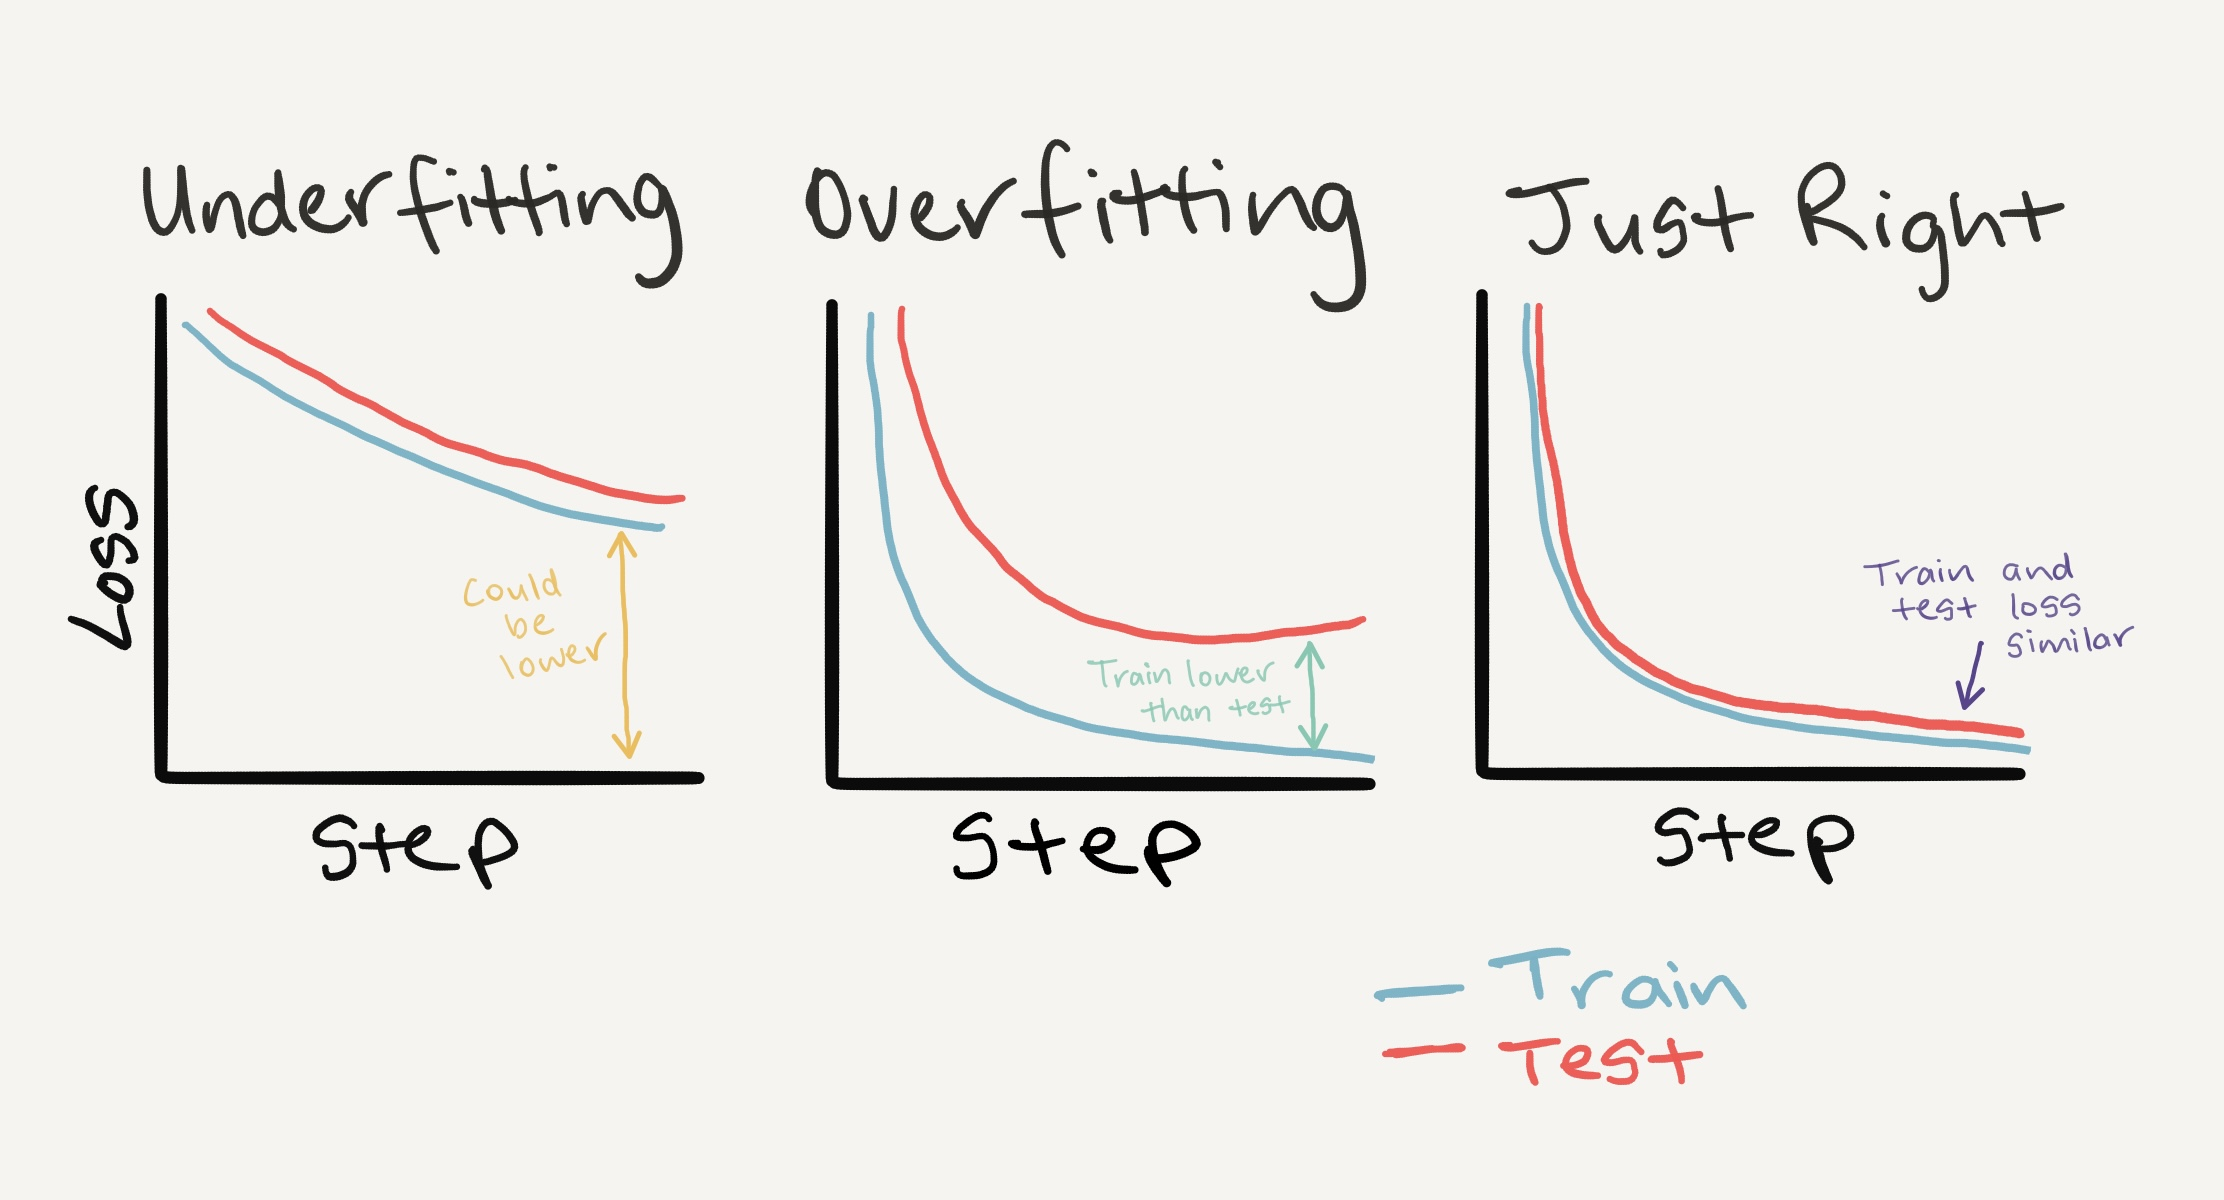

### 9. model 1 : TinyVGG with data Agumentaion

#### 9.1  Create transform with data agumentaion

In [60]:
from torchvision import  transforms
train_transform_trivial = transforms.Compose([
                                            transforms.Resize(size=(64,64)),
                                            transforms.TrivialAugmentWide(num_magnitude_bins=31),
                                            transforms.ToTensor()
])

test_transform_simple = transforms.Compose([
                                        transforms.Resize(size=(64,64)),
                                        transforms.ToTensor()
])


#### 9.2 Create train and test `Dataset's` and `Dataloader's` with data agumentaion

In [61]:
# turn img folder into dataset
from torchvision import datasets
train_data_agumented = datasets.ImageFolder(root=train_dir,
                                            transform= train_transform_trivial)
test_data_simple = datasets.ImageFolder(root=test_dir,
                                        transform=test_transform_simple)

#### Turn Dataset into DataLaosder

In [62]:
import os
from torch.utils.data import DataLoader
BATCH_SIZE = 32 
NUM_WORKERS = os.cpu_count()
torch.manual_seed(42)
train_dataloader_agumented = DataLoader(dataset= train_data_agumented,
                                      batch_size=BATCH_SIZE,
                                      num_workers=NUM_WORKERS,
                                      shuffle=True
                                      )
test_dataloader_simplee = DataLoader(dataset=test_data_simple,
                                     batch_size=BATCH_SIZE,
                                     num_workers=NUM_WORKERS,
                                     shuffle=False)

### 9.3 Consruct and train model 1 with data agumentaion

In [63]:
torch.manual_seed(42)
model_1 = TinyVGG(input_shape=3,
                  hidden_units=10,
                  output_shape=len(train_data_agumented.classes)).to(device)
model_1


TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=3, bias=True)
  )
)

### Now let's Train our model

In [64]:
## set random Seed
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# set no. of Epochs
NUM_EPOCHS = 5

# setup loss fuctuion

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_1.parameters(),
                             lr=0.001)

## Start the timer 

from timeit import default_timer as timer 
start_time = timer()
## train model

model_1_results = train(model=model_1,
                        train_dataloader=train_dataloader_agumented,
                        test_dataloader=test_dataloader_simplee,
                        optimizer= optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS,
                        )
 #  End timer
end_time = timer()
time_taken = end_time - start_time
print(f" Time taken by model to train {time_taken:.3f}sec.") 

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch : 1 | tarin_loss : 1.1045 | train_acc : 0.2500 | test_loss: 1.1016 | test_acc : 0.2604 
Epoch : 2 | tarin_loss : 1.0760 | train_acc : 0.4258 | test_loss: 1.1317 | test_acc : 0.2604 
Epoch : 3 | tarin_loss : 1.0730 | train_acc : 0.4258 | test_loss: 1.1706 | test_acc : 0.2604 
Epoch : 4 | tarin_loss : 1.1223 | train_acc : 0.3047 | test_loss: 1.1541 | test_acc : 0.2604 
Epoch : 5 | tarin_loss : 1.0733 | train_acc : 0.4727 | test_loss: 1.1494 | test_acc : 0.2812 
 Time taken by model to train 131.786sec.


#### 9.4 polt loss curve for model 1

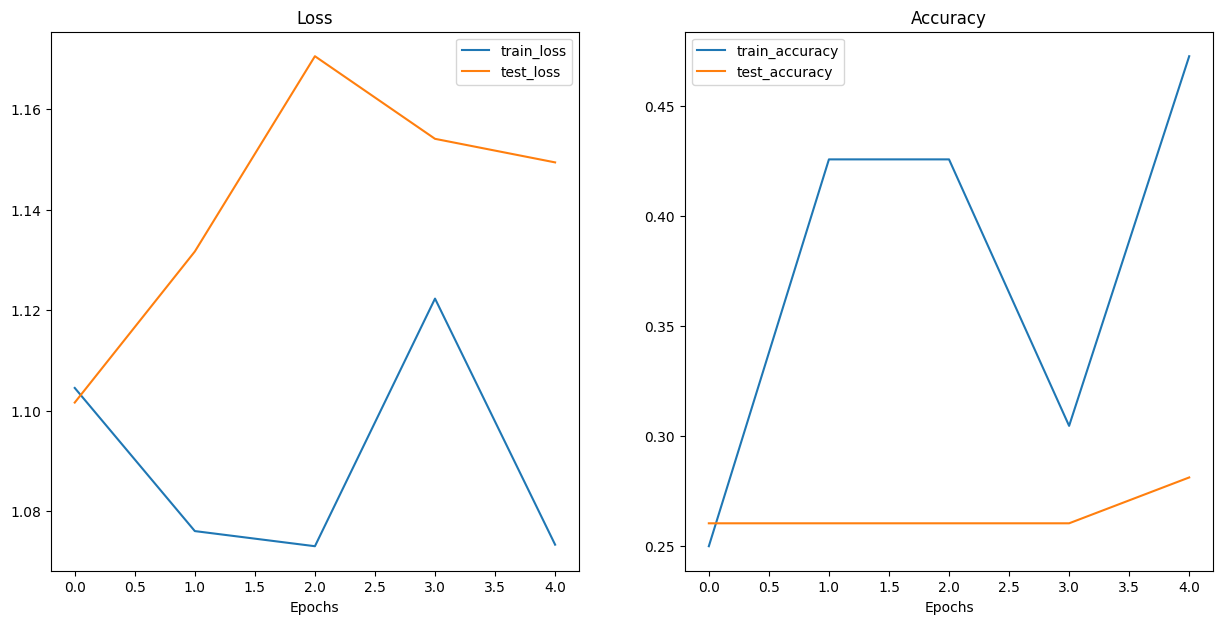

In [65]:
plot_loss_curves(model_1_results)

### 10. Comparing model 0 and model 1 results

There are few different ways we could compare the results of model 0 and model 1.

1. hard coding  (What we are doing)
2. PyTorch + tensorboard 
3. Weight and bias (wandb) - a popular third-party experiment tracking tool.
4. MLFlow - an open-source platform for managing the machine learning lifecycle.

In [66]:
import pandas as pd
model_0_df = pd.DataFrame(model_0_results)
model_1_df = pd.DataFrame(model_1_results)
model_0_df

,train_loss,train_acc,test_loss,test_acc
0,1.106319,0.304688,1.098321,0.301136
1,1.099790,0.328125,1.069725,0.541667
2,1.086885,0.488281,1.080783,0.492424
3,1.084378,0.398438,1.060713,0.583333
4,1.066304,0.417969,1.065691,0.564394


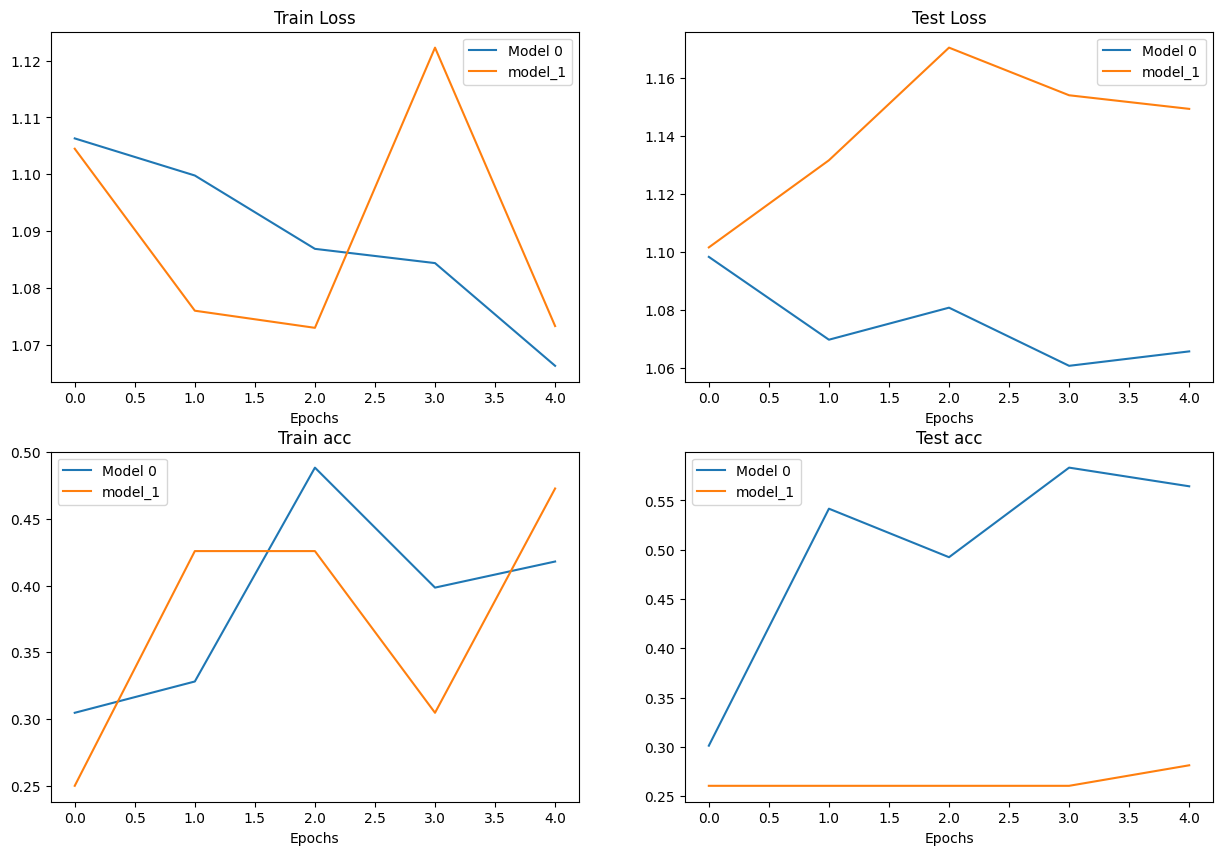

In [72]:
## Plot model_0 and Model_1 
plt.figure(figsize=(15,10))

# get no. of Epochs
epochs = range(len(model_0_df))

# plot train loss 
plt.subplot(2,2,1)
plt.plot(epochs, model_0_df["train_loss"] , label="Model 0")
plt.plot(epochs, model_1_df["train_loss"], label="model_1")
plt.title("Train Loss")
plt.xlabel("Epochs")
plt.legend()

# Plot test loss
plt.subplot(2,2,2)
plt.plot(epochs, model_0_df["test_loss"] , label="Model 0")
plt.plot(epochs, model_1_df["test_loss"], label="model_1")
plt.title("Test Loss")
plt.xlabel("Epochs")
plt.legend()

# plot the train Accuracy
plt.subplot(2,2,3)
plt.plot(epochs, model_0_df["train_acc"] , label="Model 0")
plt.plot(epochs, model_1_df["train_acc"], label="model_1")
plt.title("Train acc")
plt.xlabel("Epochs")
plt.legend()

# plot the test Accuarcy
plt.subplot(2,2,4)
plt.plot(epochs, model_0_df["test_acc"] , label="Model 0")
plt.plot(epochs, model_1_df["test_acc"], label="model_1")
plt.title("Test acc")
plt.xlabel("Epochs")
plt.legend()



### 11. Make a prediction on a custom image

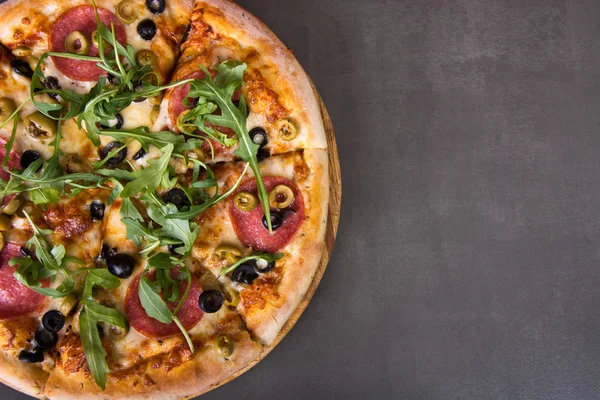

In [74]:
## Download Custom image
import requests

# or if in local system

from pathlib import Path
from PIL import Image

# setup custom  image path
custom_image_path = data_path / "stock-photo-pizza.jpg"

image_path = Path(r"C:\Users\Pranav\Downloads\stock-photo-pizza.jpg")

img = Image.open(image_path)
img

# Donload the image if it doesn't exist
# if not custom_image_path.is_file():
#     with open(custom_image_path, "wb") as f:
#         # When downloading from GitHub, need to use the "raw" file link
#         request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg")
#         print(f"Downloading {custom_image_path}...")
#         f.write(request.content)
# else:
#     print(f"{custom_image_path} already exists, skipping download.")

### 11.1 Loading in a custom image with PyTorch

PyTorch's `torchvision` has several input and output ("IO" or "io" for short) methods for reading and writing images and video in torchvision.io.

Since we want to load in an image, we'll use `torchvision.io.read_image().`

This method will read a JPEG or PNG image and turn it into a 3 dimensional RGB or grayscale torch.Tensor with values of datatype `uint8` in range `[0, 255].`

In [77]:
image_path  # this is windows path there are other types of path too like PosixPath so we convert it to str in below code

WindowsPath('C:/Users/Pranav/Downloads/stock-photo-pizza.jpg')

In [75]:
import torchvision

# Read in custom image
custom_image_uint8 = torchvision.io.read_image(str(image_path))

# Print out image data
print(f"Custom image tensor:\n{custom_image_uint8}\n")
print(f"Custom image shape: {custom_image_uint8.shape}\n")
print(f"Custom image dtype: {custom_image_uint8.dtype}")

Custom image tensor:
tensor([[[ 60,  55,  54,  ...,  84,  84,  84],
         [ 57,  57,  59,  ...,  84,  84,  84],
         [ 57,  65,  93,  ...,  84,  84,  84],
         ...,
         [ 70,  70,  70,  ...,  84,  91,  92],
         [ 71,  71,  71,  ...,  86,  84,  85],
         [ 71,  71,  71,  ...,  88,  88,  93]],

        [[ 46,  38,  35,  ...,  77,  77,  77],
         [ 37,  38,  38,  ...,  77,  77,  77],
         [ 31,  37,  63,  ...,  77,  77,  77],
         ...,
         [ 67,  67,  67,  ...,  87,  94,  95],
         [ 68,  68,  68,  ...,  89,  87,  88],
         [ 68,  68,  68,  ...,  90,  90,  96]],

        [[ 64,  58,  55,  ...,  79,  79,  79],
         [ 58,  55,  57,  ...,  79,  79,  79],
         [ 51,  56,  77,  ...,  79,  79,  79],
         ...,
         [ 75,  75,  75,  ...,  97, 104, 106],
         [ 76,  76,  76,  ..., 100,  97,  99],
         [ 76,  76,  76,  ..., 101, 101, 107]]], dtype=torch.uint8)

Custom image shape: torch.Size([3, 400, 600])

Custom image dtype

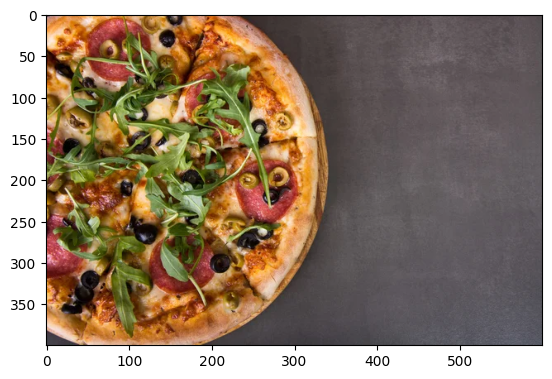

In [78]:
plt.imshow(custom_image_uint8.permute(1,2,0))

###  11.2 Predicting on custom images with a trained PyTorch model

In [79]:
# Try to make a prediction on image in uint8 format (this will error)
model_1.eval()
with torch.inference_mode():
    model_1(custom_image_uint8.to(device))

RuntimeError: Input type (unsigned char) and bias type (float) should be the same

In [80]:
# Load in custom image and convert the tensor values to float32
custom_image = torchvision.io.read_image(str(image_path)).type(torch.float32)

# Divide the image pixel values by 255 to get them between [0, 1]
custom_image = custom_image / 255. 

# Print out image data
print(f"Custom image tensor:\n{custom_image}\n")
print(f"Custom image shape: {custom_image.shape}\n")
print(f"Custom image dtype: {custom_image.dtype}")

Custom image tensor:
tensor([[[0.2353, 0.2157, 0.2118,  ..., 0.3294, 0.3294, 0.3294],
         [0.2235, 0.2235, 0.2314,  ..., 0.3294, 0.3294, 0.3294],
         [0.2235, 0.2549, 0.3647,  ..., 0.3294, 0.3294, 0.3294],
         ...,
         [0.2745, 0.2745, 0.2745,  ..., 0.3294, 0.3569, 0.3608],
         [0.2784, 0.2784, 0.2784,  ..., 0.3373, 0.3294, 0.3333],
         [0.2784, 0.2784, 0.2784,  ..., 0.3451, 0.3451, 0.3647]],

        [[0.1804, 0.1490, 0.1373,  ..., 0.3020, 0.3020, 0.3020],
         [0.1451, 0.1490, 0.1490,  ..., 0.3020, 0.3020, 0.3020],
         [0.1216, 0.1451, 0.2471,  ..., 0.3020, 0.3020, 0.3020],
         ...,
         [0.2627, 0.2627, 0.2627,  ..., 0.3412, 0.3686, 0.3725],
         [0.2667, 0.2667, 0.2667,  ..., 0.3490, 0.3412, 0.3451],
         [0.2667, 0.2667, 0.2667,  ..., 0.3529, 0.3529, 0.3765]],

        [[0.2510, 0.2275, 0.2157,  ..., 0.3098, 0.3098, 0.3098],
         [0.2275, 0.2157, 0.2235,  ..., 0.3098, 0.3098, 0.3098],
         [0.2000, 0.2196, 0.3020,  ..

In [82]:
# Create transform pipleine to resize image
custom_image_transform = transforms.Compose([
    transforms.Resize((64, 64)),
])

# Transform target image
custom_image_transformed = custom_image_transform(custom_image)

# Print out original shape and new shape
print(f"Original shape: {custom_image.shape}")
print(f"New shape: {custom_image_transformed.shape}")

Original shape: torch.Size([3, 400, 600])
New shape: torch.Size([3, 64, 64])


In [84]:
model_1.eval()
with torch.inference_mode():
    custom_image_pred = model_1(custom_image_transformed.to(device))

RuntimeError: mat1 and mat2 shapes cannot be multiplied (10x169 and 1690x3)

In [85]:
model_1.eval()
with torch.inference_mode():
    # Add an extra dimension to image
    custom_image_transformed_with_batch_size = custom_image_transformed.unsqueeze(dim=0)
    
    # Print out different shapes
    print(f"Custom image transformed shape: {custom_image_transformed.shape}")
    print(f"Unsqueezed custom image shape: {custom_image_transformed_with_batch_size.shape}")
    
    # Make a prediction on image with an extra dimension
    custom_image_pred = model_1(custom_image_transformed.unsqueeze(dim=0).to(device))

Custom image transformed shape: torch.Size([3, 64, 64])
Unsqueezed custom image shape: torch.Size([1, 3, 64, 64])


* **Note**: What we've just gone through are three of the classical and most common deep learning and PyTorch issues:

1. **Wrong datatypes** - our model expects` torch.float32` where our original custom image was `uint8.`
2. **Wrong device** - our model was on the target `device` (in our case, the GPU) whereas our target data hadn't been moved to the target device yet.
3. **Wrong shapes** - our model expected an input image of shape `[N, C, H, W]` or `[batch_size, color_channels, height, width]` whereas our custom image tensor was of shape `[color_channels, height, width]`.
Keep in mind, these errors aren't just for predicting on custom images.

They will be present with almost every kind of data type (text, audio, structured data) and problem you work with.

In [86]:
custom_image_pred

tensor([[ 0.0479,  0.0584, -0.1848]], device='cuda:0')

Alright, these are still in logit form (the raw outputs of a model are called logits).

* Let's convert them from logits -> prediction probabilities -> prediction labels.

In [87]:
# Print out prediction logits
print(f"Prediction logits: {custom_image_pred}")

# Convert logits -> prediction probabilities (using torch.softmax() for multi-class classification)
custom_image_pred_probs = torch.softmax(custom_image_pred, dim=1)
print(f"Prediction probablities : {custom_image_pred_probs}")

# Convert prediction probabilities -> prediction labels
custom_image_pred_label  = torch.argmax(custom_image_pred_probs, dim=1)
print(f"Prediction labels : {custom_image_pred_label}")


Prediction logits: tensor([[ 0.0479,  0.0584, -0.1848]], device='cuda:0')
Prediction probablities : tensor([[0.3568, 0.3605, 0.2827]], device='cuda:0')
Prediction labels : tensor([1], device='cuda:0')


In [88]:
## find peredicted label
custom_image_pred_class = class_names[custom_image_pred_label.cpu()] # put pred label to CPU, otherwise will error
custom_image_pred_class

'steak'

WE got wrong class predicted due to poor performance of model 1. We can improve the performance of model 1 by increasing the number of epochs and also by using a more complex model architecture.

In [89]:
# The values of the prediction probabilities are quite similar
custom_image_pred_probs

tensor([[0.3568, 0.3605, 0.2827]], device='cuda:0')


Having prediction probabilities this similar could mean a couple of things:

1. The model is trying to predict all three classes at the same time (there may be an image containing pizza, steak and sushi).
2. The model doesn't really know what it wants to predict and is in turn just assigning similar values to each of the classes.
Our case is number 2, since our model is poorly trained, it is basically guessing the prediction.

### 11.3 Putting custom image prediction together: building a function

Doing all of the above steps every time you'd like to make a prediction on a custom image would quickly become tedious.

So let's put them all together in a function we can easily use over and over again.

Specifically, let's make a function that:

1. Takes in a target image path and converts to the right datatype for our model (torch.float32).
2. Makes sure the target image pixel values are in the range [0, 1].
3. Transforms the target image if necessary.
4. Makes sure the model is on the target device.
5. Makes a prediction on the target image with a trained model (ensuring the image is the right size and on the same device as the model).
6. Converts the model's output logits to prediction probabilities.
7. Converts the prediction probabilities to prediction labels.
8. Plots the target image alongside the model prediction and prediction probability.

In [ ]:
def pred_and_plot_image(model: torch.nn.Module,
                        image_path: str,
                        class_names: List[str] = None,
                        transform = None,
                        device = torch.device):
    ''' Makes a prediction on a target image and plots the image with it;s prediction '''
    # 1. Load in image and convert the tensor values to float32
    target_image = torchvision.io.read_image(str(image_path)).type(torch.float32)



    # 2. Divide the image pixel values by 255 to get them between [0, 1]
    target_image /= 255

    # 3. transform is necessary
    if transform:
        target_image = transform(target_image)

    # 4. make sure the model is on the target device 
    model.to(device)

    # 5. Trun on modes evaluation and inference mode
    model.eval()
    with torch.inference_mode():
        # add extra dimension to the image
        target_image = target_image.unsqueeze(dim=0)

        # Make a prediction on image with an extra dimension and send it to the target device
        target_image_pred = model(target_image.to(device))

    # 6. Convert logits -> prediction probablities (using torch.softmax() for multi-class classification)
    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)
    
    # 7. Convert prediction probabilities -> prediction labels
    target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)

    # 8. Plot the image alongside the prediction and prediction probability
    plt.imshow(target_image.squeeze().permute(1, 2, 0)) # make sure it's the right size for matplotlib
    if class_names:
        title = f"Pred: {class_names[target_image_pred_label.cpu()]} | Prob: {target_image_pred_probs.max().cpu():.3f}"
    else: 
        title = f"Pred: {target_image_pred_label} | Prob: {target_image_pred_probs.max().cpu():.3f}"
    plt.title(title)
    plt.axis(False);
    


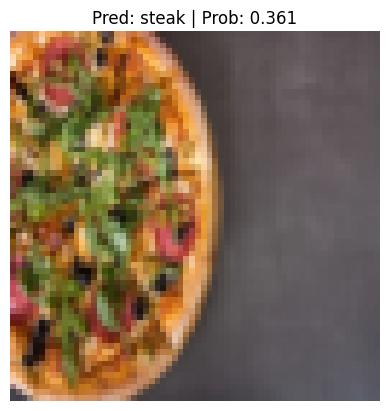

In [93]:
# Pred on our custom image
pred_and_plot_image(model=model_1,
                    image_path=image_path,
                    class_names=class_names,
                    transform=custom_image_transform,
                    device=device)